HYBRID CNN-BASED BRAIN TUMOR CLASSIFICATION WITH COMPARATIVE ANALYSIS
Dataset: Brain Tumor MRI (4 Classes: glioma, meningioma, pituitary, no_tumor)
Platform: Kaggle (GPU T4 enabled)
Framework: TensorFlow/Keras + PyTorch (GAN)

# SECTION 0: IMPORTS & SETUP

In [1]:
import os
import random
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter
 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.utils import save_image
 
warnings.filterwarnings("ignore")

2026-05-02 05:21:39.361208: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777699299.555051      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777699299.608999      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777699300.080625      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777699300.080663      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777699300.080666      57 computation_placer.cc:177] computation placer alr

# Reproducibility

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Paths 

In [3]:
BASE_DIR      = Path("/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset")   # adjust if needed
WORKING_DIR   = Path("/kaggle/working")
GAN_SAVE_DIR  = WORKING_DIR / "gan_generated"
AUG_DATA_DIR  = WORKING_DIR / "augmented_dataset"
GAN_SAVE_DIR.mkdir(parents=True, exist_ok=True)
AUG_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Hyper-parameters

In [4]:
IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS_BASE  = 50
EPOCHS_FINE  = 10
LR           = 1e-4
NUM_CLASSES  = 4
CLASSES      = ["glioma", "meningioma", "notumor", "pituitary"]
 
print("TensorFlow :", tf.__version__)
print("PyTorch    :", torch.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow : 2.19.0
PyTorch    : 2.10.0+cu128
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# SECTION 1: DATA LOADING & SPLITTING

In [5]:
def discover_dataset(base_dir: Path):
    """
    Supports two common Kaggle folder layouts:
      Layout A: base_dir/{Training,Testing}/{class}/...
      Layout B: base_dir/{class}/...
    Returns a flat list of (filepath, label) tuples.
    """
    samples = []
    # Layout A
    for split in ["Training", "Testing"]:
        split_path = base_dir / split
        if split_path.exists():
            for cls in CLASSES:
                cls_path = split_path / cls
                if not cls_path.exists():
                    # try case-insensitive match
                    for d in split_path.iterdir():
                        if d.name.lower() == cls.lower():
                            cls_path = d
                            break
                for img in cls_path.glob("*.jpg"):
                    samples.append((str(img), cls))
                for img in cls_path.glob("*.png"):
                    samples.append((str(img), cls))
    # Layout B fallback
    if not samples:
        for cls in CLASSES:
            cls_path = base_dir / cls
            for img in cls_path.glob("*.*"):
                if img.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                    samples.append((str(img), cls))
    print(f"Total images found: {len(samples)}")
    counts = Counter([s[1] for s in samples])
    for c in CLASSES:
        print(f"  {c:>12}: {counts.get(c, 0)}")
    return samples
 
 
def split_data(samples, val_size=0.15, test_size=0.15):
    """Stratified train / val / test split with no data leakage."""
    paths  = [s[0] for s in samples]
    labels = [s[1] for s in samples]
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        paths, labels, test_size=val_size + test_size,
        stratify=labels, random_state=SEED)
    ratio = test_size / (val_size + test_size)
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=ratio, stratify=y_tmp, random_state=SEED)
    print(f"\nSplit  → Train: {len(X_tr)}  Val: {len(X_val)}  Test: {len(X_te)}")
    return (X_tr, y_tr), (X_val, y_val), (X_te, y_te)

# Build dataset

In [6]:
all_samples = discover_dataset(BASE_DIR)
train_data, val_data, test_data = split_data(all_samples)
 
label2idx = {c: i for i, c in enumerate(CLASSES)}
idx2label = {i: c for c, i in label2idx.items()}

Total images found: 7200
        glioma: 1800
    meningioma: 1800
       notumor: 1800
     pituitary: 1800

Split  → Train: 5040  Val: 1080  Test: 1080


# SECTION 2: DATA GENERATORS (NO AUGMENTATION)

In [7]:
def make_generators(train_d, val_d, test_d, augment=False):
    """
    Returns Keras generators.
    augment=False → only rescaling (baseline / hybrid CNN experiments).
    augment=True  → controlled augmentation.
    """
    if augment:
        train_datagen = ImageDataGenerator(
            rescale=1.0 / 255,
            rotation_range=20,
            zoom_range=0.15,
            brightness_range=[0.8, 1.2],
            horizontal_flip=True,
            fill_mode="nearest",
        )
    else:
        train_datagen = ImageDataGenerator(rescale=1.0 / 255)
 
    val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)
 
    def from_lists(datagen, paths, labels, shuffle=True):
        df = pd.DataFrame({"filename": paths, "class": labels})
        return datagen.flow_from_dataframe(
            df, x_col="filename", y_col="class",
            target_size=(IMG_SIZE, IMG_SIZE),
            batch_size=BATCH_SIZE,
            class_mode="categorical",
            classes=CLASSES,
            shuffle=shuffle,
            seed=SEED,
        )
 
    train_gen = from_lists(train_datagen,  *train_d, shuffle=True)
    val_gen   = from_lists(val_test_datagen, *val_d,   shuffle=False)
    test_gen  = from_lists(val_test_datagen, *test_d,  shuffle=False)
    return train_gen, val_gen, test_gen
 
 
train_gen_noaug, val_gen, test_gen = make_generators(train_data, val_data, test_data, augment=False)

Found 5040 validated image filenames belonging to 4 classes.
Found 1080 validated image filenames belonging to 4 classes.
Found 1080 validated image filenames belonging to 4 classes.


# SECTION 3: UTILITY — EVALUATION

In [8]:
def evaluate_model(model, test_generator, title="Model"):
    """Full evaluation: accuracy, precision, recall, F1, confusion matrix."""
    test_generator.reset()
    y_pred_prob = model.predict(test_generator, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = test_generator.classes
 
    # Overall accuracy
    acc = np.mean(y_pred == y_true)
    print(f"\n{'='*55}")
    print(f"  {title}")
    print(f"{'='*55}")
    print(f"  Overall Accuracy : {acc*100:.2f}%")
 
    # Per-class metrics
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred,
                                                  labels=list(range(NUM_CLASSES)),
                                                  zero_division=0)
    macro_f1 = np.mean(f)
    print(f"  Macro F1-Score   : {macro_f1*100:.2f}%")
    print(f"\n{classification_report(y_true, y_pred, target_names=CLASSES, zero_division=0)}")
 
    return y_true, y_pred, acc, p, r, f
 
 
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True",      fontsize=12)
    ax.set_title(title,        fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(WORKING_DIR / f"cm_{title.replace(' ','_')}.png", dpi=150)
    plt.show()
 
 
def plot_history(history, title="Training Curves"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history["accuracy"],     label="Train Acc")
    axes[0].plot(history.history["val_accuracy"], label="Val Acc")
    axes[0].set_title(f"{title} — Accuracy")
    axes[0].legend(); axes[0].set_xlabel("Epoch")
 
    axes[1].plot(history.history["loss"],     label="Train Loss")
    axes[1].plot(history.history["val_loss"], label="Val Loss")
    axes[1].set_title(f"{title} — Loss")
    axes[1].legend(); axes[1].set_xlabel("Epoch")
 
    plt.tight_layout()
    plt.savefig(WORKING_DIR / f"hist_{title.replace(' ','_')}.png", dpi=150)
    plt.show()

# EXPERIMENT 1: BASELINE — RESNET50 (NO AUGMENTATION)


────────────────────────────────────────────────────────────
EXPERIMENT 1: ResNet50 Baseline (no augmentation)
────────────────────────────────────────────────────────────


I0000 00:00:1777699340.216266      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777699340.223061      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ResNet50_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

Epoch 1/50


I0000 00:00:1777699350.891256     129 service.cc:152] XLA service 0x7a0b3c0023c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777699350.891291     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777699350.891295     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777699352.729980     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/158 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.1719 - loss: 1.9991 

I0000 00:00:1777699357.805671     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


158/158 ━━━━━━━━━━━━━━━━━━━━ 58s 283ms/step - accuracy: 0.3122 - loss: 1.4726 - val_accuracy: 0.5454 - val_loss: 1.1663 - learning_rate: 1.0000e-04
Epoch 2/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - accuracy: 0.4484 - loss: 1.1954 - val_accuracy: 0.6333 - val_loss: 1.1007 - learning_rate: 1.0000e-04
Epoch 3/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 105ms/step - accuracy: 0.5348 - loss: 1.1021 - val_accuracy: 0.6343 - val_loss: 1.0578 - learning_rate: 1.0000e-04
Epoch 4/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - accuracy: 0.5675 - loss: 1.0640 - val_accuracy: 0.6074 - val_loss: 1.0306 - learning_rate: 1.0000e-04
Epoch 5/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.6007 - loss: 1.0273 - val_accuracy: 0.6056 - val_loss: 1.0023 - learning_rate: 1.0000e-04
Epoch 6/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 19s 118ms/step - accuracy: 0.6099 - loss: 0.9911 - val_accuracy: 0.6426 - val_loss: 0.9819 - learning_rate: 1.0000e-04
Epoch 7/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 19s 122ms/step - 

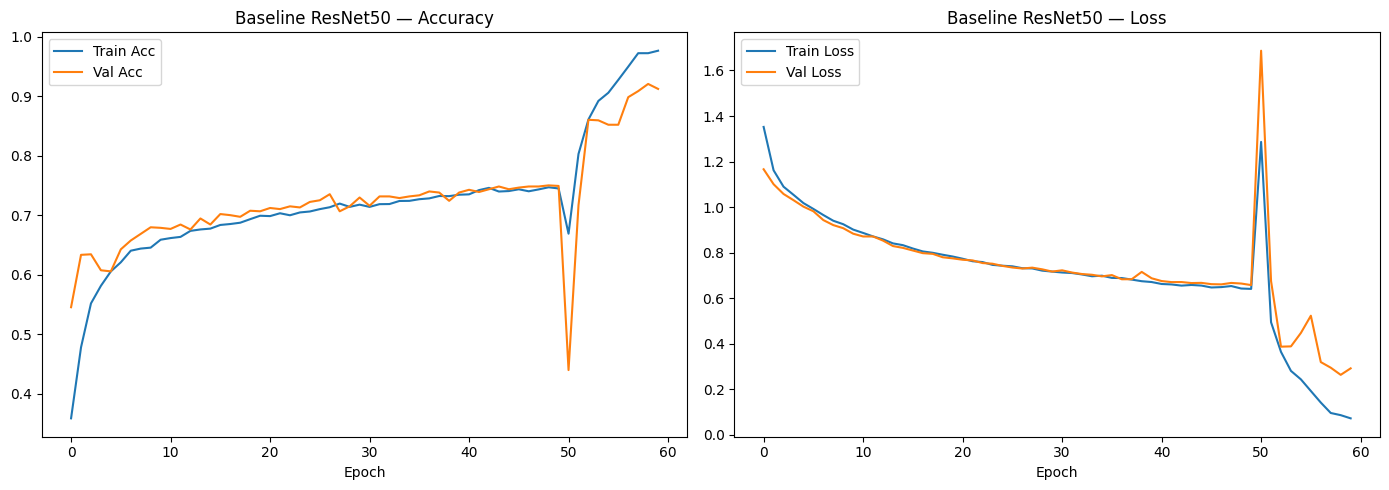


  Baseline ResNet50
  Overall Accuracy : 90.83%
  Macro F1-Score   : 90.81%

              precision    recall  f1-score   support

      glioma       0.95      0.84      0.89       270
  meningioma       0.83      0.87      0.85       270
     notumor       0.94      0.96      0.95       270
   pituitary       0.93      0.97      0.95       270

    accuracy                           0.91      1080
   macro avg       0.91      0.91      0.91      1080
weighted avg       0.91      0.91      0.91      1080



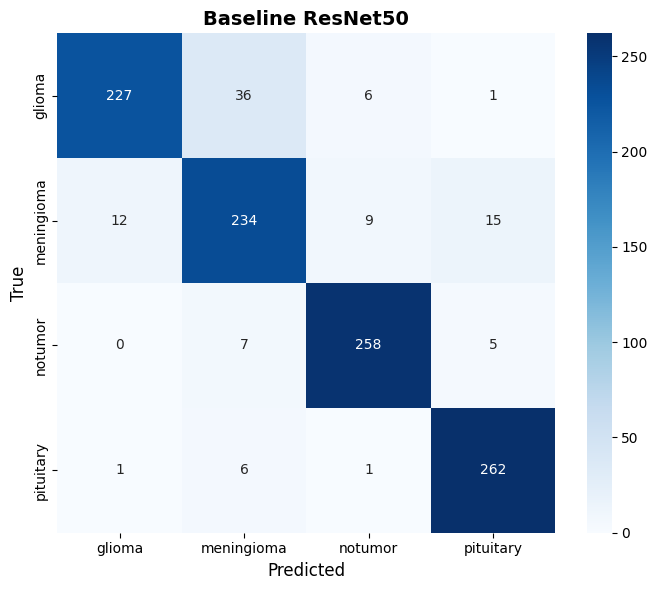

In [9]:
print("\n" + "─"*60)
print("EXPERIMENT 1: ResNet50 Baseline (no augmentation)")
print("─"*60)
 
def build_resnet50_baseline():
    base = ResNet50(weights="imagenet", include_top=False,
                    input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False   # freeze entire base initially
 
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
 
    model = keras.Model(inputs, outputs, name="ResNet50_Baseline")
    model.compile(optimizer=keras.optimizers.Adam(LR),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model, base
 
 
baseline_model, resnet_base = build_resnet50_baseline()
baseline_model.summary()
 
cb_list = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss"),
    callbacks.ReduceLROnPlateau(patience=3, factor=0.5, min_lr=1e-7, monitor="val_loss"),
]
 
# Phase 1: frozen base
hist1 = baseline_model.fit(
    train_gen_noaug, validation_data=val_gen,
    epochs=EPOCHS_BASE, callbacks=cb_list, verbose=1)
 
# Phase 2: fine-tune top 30 layers
resnet_base.trainable = True
for layer in resnet_base.layers[:-30]:
    layer.trainable = False
 
baseline_model.compile(optimizer=keras.optimizers.Adam(1e-5),
                        loss="categorical_crossentropy", metrics=["accuracy"])
 
hist2 = baseline_model.fit(
    train_gen_noaug, validation_data=val_gen,
    epochs=EPOCHS_FINE, callbacks=cb_list, verbose=1)
 
# Merge histories for plotting
def merge_hist(h1, h2):
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history[k]
    class FakeHist: history = merged
    return FakeHist()
 
baseline_hist = merge_hist(hist1, hist2)
plot_history(baseline_hist, "Baseline ResNet50")
 
y_true_b, y_pred_b, acc_b, p_b, r_b, f_b = evaluate_model(
    baseline_model, test_gen, title="Baseline ResNet50")
plot_confusion_matrix(y_true_b, y_pred_b, "Baseline ResNet50")
baseline_model.save(str(WORKING_DIR / "baseline_resnet50.h5"))

# EXPERIMENT 2: CUSTOM HYBRID CNN


────────────────────────────────────────────────────────────
EXPERIMENT 2: Custom Hybrid CNN
────────────────────────────────────────────────────────────


Model: "HybridCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,472 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 56, 56,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_4[0][0]  

 Total params: 2,851,844 (10.88 MB)

 Trainable params: 2,847,428 (10.86 MB)

 Non-trainable params: 4,416 (17.25 KB)

Epoch 1/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 63s 231ms/step - accuracy: 0.5142 - loss: 1.1183 - val_accuracy: 0.2491 - val_loss: 2.6681 - learning_rate: 1.0000e-04
Epoch 2/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - accuracy: 0.7772 - loss: 0.6241 - val_accuracy: 0.2917 - val_loss: 3.7123 - learning_rate: 1.0000e-04
Epoch 3/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - accuracy: 0.8384 - loss: 0.4742 - val_accuracy: 0.4296 - val_loss: 1.6787 - learning_rate: 1.0000e-04
Epoch 4/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - accuracy: 0.8743 - loss: 0.3888 - val_accuracy: 0.6954 - val_loss: 0.8719 - learning_rate: 1.0000e-04
Epoch 5/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - accuracy: 0.8926 - loss: 0.3385 - val_accuracy: 0.5620 - val_loss: 2.5831 - learning_rate: 1.0000e-04
Epoch 6/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - accuracy: 0.9035 - loss: 0.3024 - val_accuracy: 0.7694 - val_loss: 0.6589 - learning_rate: 1.0000e-04
Epoch 7/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 10

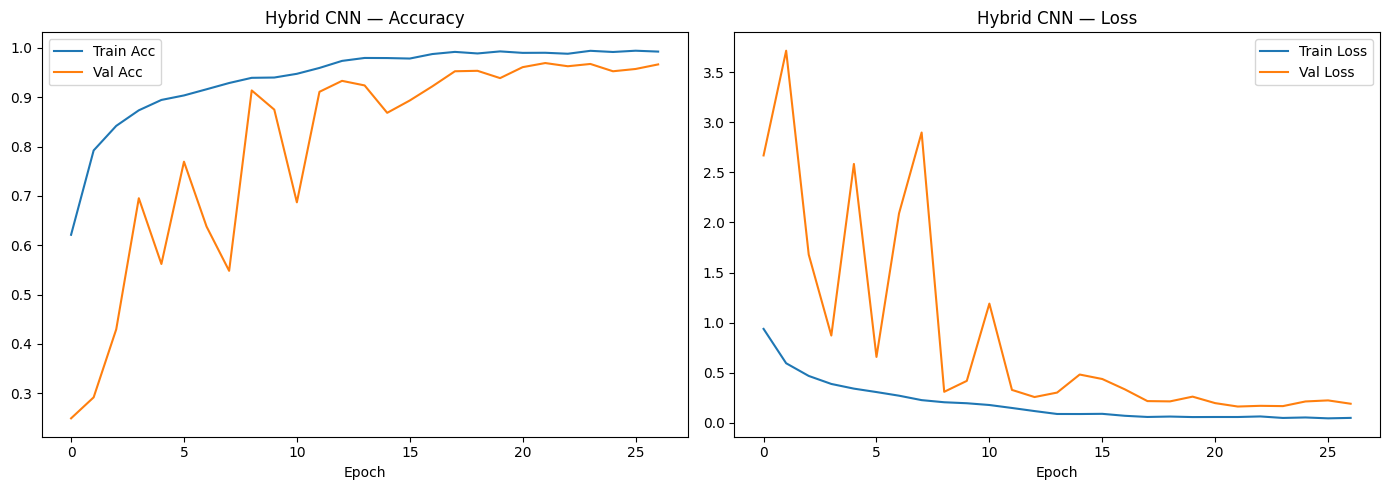


  Hybrid CNN
  Overall Accuracy : 95.09%
  Macro F1-Score   : 95.07%

              precision    recall  f1-score   support

      glioma       0.94      0.93      0.93       270
  meningioma       0.93      0.91      0.92       270
     notumor       0.97      0.97      0.97       270
   pituitary       0.96      0.99      0.97       270

    accuracy                           0.95      1080
   macro avg       0.95      0.95      0.95      1080
weighted avg       0.95      0.95      0.95      1080



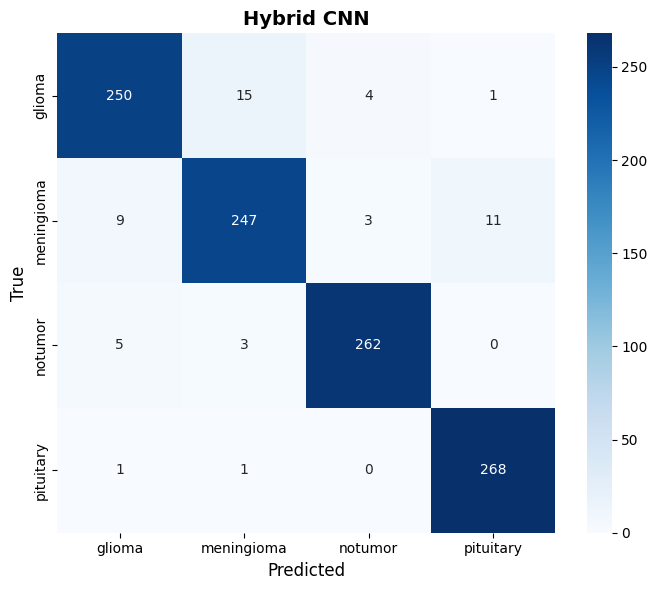

In [10]:
print("\n" + "─"*60)
print("EXPERIMENT 2: Custom Hybrid CNN")
print("─"*60)
 
def inception_block(x, f1, f3, f5):
    """Multi-scale Inception-style block."""
    b1 = layers.Conv2D(f1, 1, padding="same", activation="relu")(x)
 
    b3 = layers.Conv2D(f3, 1, padding="same", activation="relu")(x)
    b3 = layers.Conv2D(f3, 3, padding="same", activation="relu")(b3)
 
    b5 = layers.Conv2D(f5, 1, padding="same", activation="relu")(x)
    b5 = layers.Conv2D(f5, 5, padding="same", activation="relu")(b5)
 
    pool = layers.MaxPooling2D(3, strides=1, padding="same")(x)
    pool = layers.Conv2D(f1, 1, padding="same", activation="relu")(pool)
 
    return layers.Concatenate()([b1, b3, b5, pool])
 
 
def residual_block(x, filters, downsample=False):
    """Residual block with optional spatial downsampling."""
    stride = 2 if downsample else 1
    shortcut = x
 
    x = layers.Conv2D(filters, 3, strides=stride, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
 
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
 
    # Adjust shortcut dimensions if needed
    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
 
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x
 
 
def build_hybrid_cnn():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
 
    # Stem
    x = layers.Conv2D(64, 7, strides=2, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(3, strides=2, padding="same")(x)
 
    # Stage 1: Residual blocks
    x = residual_block(x, 64)
    x = residual_block(x, 64)
 
    # Stage 2: Inception + residual
    x = inception_block(x, 32, 64, 32)       # out: 32+64+32+32 = 160 channels
    x = layers.MaxPooling2D(2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)
 
    x = residual_block(x, 128, downsample=True)
    x = residual_block(x, 128)
 
    # Stage 3: deeper inception
    x = inception_block(x, 64, 128, 64)      # out: 64+128+64+64 = 320
    x = layers.MaxPooling2D(2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)
 
    x = residual_block(x, 256, downsample=True)
 
    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
 
    model = keras.Model(inputs, outputs, name="HybridCNN")
    model.compile(optimizer=keras.optimizers.Adam(LR),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model
 
 
hybrid_model = build_hybrid_cnn()
hybrid_model.summary()
 
train_gen_noaug.reset()
hist_hybrid = hybrid_model.fit(
    train_gen_noaug, validation_data=val_gen,
    epochs=EPOCHS_BASE + EPOCHS_FINE, callbacks=cb_list, verbose=1)
 
plot_history(hist_hybrid, "Hybrid CNN")
y_true_h, y_pred_h, acc_h, p_h, r_h, f_h = evaluate_model(
    hybrid_model, test_gen, title="Hybrid CNN")
plot_confusion_matrix(y_true_h, y_pred_h, "Hybrid CNN")
hybrid_model.save(str(WORKING_DIR / "hybrid_cnn.h5"))

# EXPERIMENT 3: ATTENTION-ENHANCED HYBRID CNN (SE Blocks + Class Weighting)


────────────────────────────────────────────────────────────
EXPERIMENT 3: Attention-Enhanced Hybrid CNN (SE Blocks)
────────────────────────────────────────────────────────────
Class weights: {'glioma': np.float64(1.0), 'meningioma': np.float64(1.0), 'notumor': np.float64(1.0), 'pituitary': np.float64(1.0)}


Model: "AttentionHybridCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 112, 112,  │      9,472 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 56, 56,    │          0 │ activation_11[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 56, 56,    │     36,928 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_26[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 56, 56,    │     36,928 │ activation_12[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_27[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │        320 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 56, 56,    │          0 │ multiply[0][0],   │
│                     │ 64)               │            │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 56, 56,    │          0 │ add_5[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 56, 56,    │     36,928 │ activation_13[0]

 Total params: 2,882,346 (11.00 MB)

 Trainable params: 2,877,930 (10.98 MB)

...

158/158 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - accuracy: 0.8823 - loss: 0.3730 - val_accuracy: 0.7657 - val_loss: 0.7413 - learning_rate: 1.0000e-04
Epoch 5/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9040 - loss: 0.2966

158/158 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - accuracy: 0.9040 - loss: 0.2967 - val_accuracy: 0.8870 - val_loss: 0.3523 - learning_rate: 1.0000e-04
Epoch 6/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - accuracy: 0.9219 - loss: 0.2681 - val_accuracy: 0.8509 - val_loss: 0.5187 - learning_rate: 1.0000e-04
Epoch 7/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - accuracy: 0.9233 - loss: 0.2410 - val_accuracy: 0.8870 - val_loss: 0.3331 - learning_rate: 1.0000e-04
Epoch 8/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - accuracy: 0.9440 - loss: 0.1983 - val_accuracy: 0.7102 - val_loss: 1.6956 - learning_rate: 1.0000e-04
Epoch 9/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - accuracy: 0.9412 - loss: 0.1945 - val_accuracy: 0.8796 - val_loss: 0.4378 - learning_rate: 1.0000e-04
Epoch 10/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - accuracy: 0.9455 - loss: 0.1854 - val_accuracy: 0.8130 - val_loss: 0.7295 - learning_rate: 1.0000e-04
Epoch 11/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step 

158/158 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.9708 - loss: 0.1238 - val_accuracy: 0.9213 - val_loss: 0.2960 - learning_rate: 3.0000e-05
Epoch 13/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - accuracy: 0.9758 - loss: 0.1029 - val_accuracy: 0.8880 - val_loss: 0.4422 - learning_rate: 3.0000e-05
Epoch 14/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9815 - loss: 0.0907

158/158 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.9815 - loss: 0.0907 - val_accuracy: 0.9472 - val_loss: 0.2087 - learning_rate: 3.0000e-05
Epoch 15/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - accuracy: 0.9829 - loss: 0.0797 - val_accuracy: 0.9204 - val_loss: 0.3170 - learning_rate: 3.0000e-05
Epoch 16/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - accuracy: 0.9828 - loss: 0.0758 - val_accuracy: 0.8602 - val_loss: 0.7014 - learning_rate: 3.0000e-05
Epoch 17/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - accuracy: 0.9856 - loss: 0.0751 - val_accuracy: 0.7926 - val_loss: 1.3026 - learning_rate: 3.0000e-05
Epoch 18/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - accuracy: 0.9858 - loss: 0.0747 - val_accuracy: 0.7769 - val_loss: 1.3028 - learning_rate: 3.0000e-05
Epoch 19/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9890 - loss: 0.0675

158/158 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - accuracy: 0.9890 - loss: 0.0675 - val_accuracy: 0.9602 - val_loss: 0.1850 - learning_rate: 9.0000e-06
Epoch 20/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.9886 - loss: 0.0645 - val_accuracy: 0.9361 - val_loss: 0.2660 - learning_rate: 9.0000e-06
Epoch 21/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - accuracy: 0.9919 - loss: 0.0597 - val_accuracy: 0.9306 - val_loss: 0.2918 - learning_rate: 9.0000e-06
Epoch 22/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - accuracy: 0.9924 - loss: 0.0516 - val_accuracy: 0.9537 - val_loss: 0.2164 - learning_rate: 9.0000e-06
Epoch 23/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - accuracy: 0.9907 - loss: 0.0578 - val_accuracy: 0.9250 - val_loss: 0.3451 - learning_rate: 9.0000e-06
Epoch 24/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - accuracy: 0.9909 - loss: 0.0566 - val_accuracy: 0.9435 - val_loss: 0.2608 - learning_rate: 2.7000e-06
Epoch 25/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/s

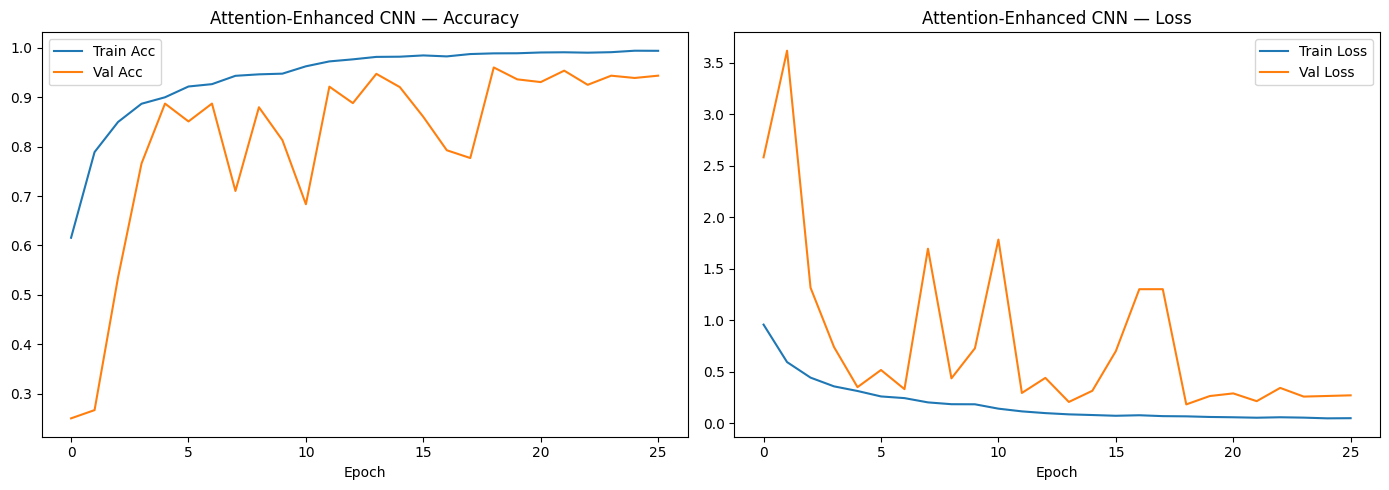


  Attention-Enhanced CNN
  Overall Accuracy : 93.52%
  Macro F1-Score   : 93.41%

              precision    recall  f1-score   support

      glioma       0.90      0.96      0.93       270
  meningioma       0.97      0.82      0.89       270
     notumor       0.96      0.97      0.97       270
   pituitary       0.92      0.99      0.95       270

    accuracy                           0.94      1080
   macro avg       0.94      0.94      0.93      1080
weighted avg       0.94      0.94      0.93      1080



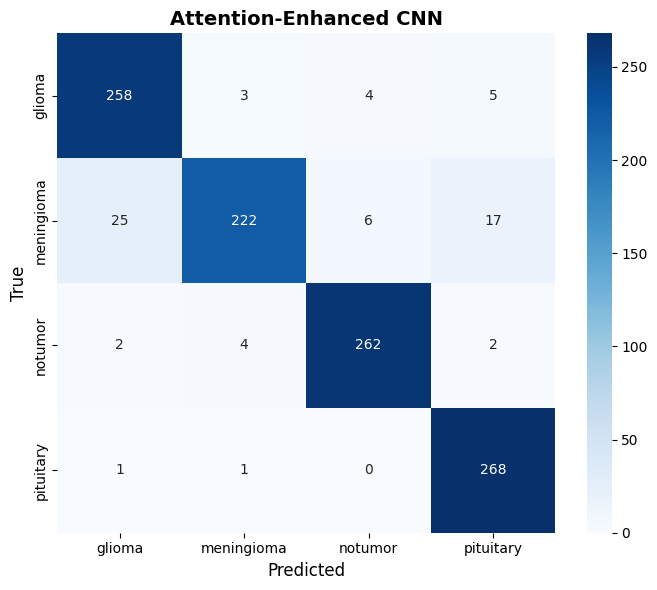

In [11]:
print("\n" + "─"*60)
print("EXPERIMENT 3: Attention-Enhanced Hybrid CNN (SE Blocks)")
print("─"*60)
 
def squeeze_excitation_block(x, ratio=16):
    """Channel-wise Squeeze-and-Excitation attention."""
    ch = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(max(ch // ratio, 1), activation="relu")(se)
    se = layers.Dense(ch, activation="sigmoid")(se)
    se = layers.Reshape((1, 1, ch))(se)
    return layers.Multiply()([x, se])
 
 
def residual_se_block(x, filters, downsample=False, ratio=16):
    """Residual block augmented with SE attention."""
    stride = 2 if downsample else 1
    shortcut = x
 
    x = layers.Conv2D(filters, 3, strides=stride, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
 
    x = squeeze_excitation_block(x, ratio)   # ← SE attention
 
    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
 
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x
 
 
def build_attention_cnn():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
 
    # Stem
    x = layers.Conv2D(64, 7, strides=2, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(3, strides=2, padding="same")(x)
 
    # Stage 1
    x = residual_se_block(x, 64)
    x = residual_se_block(x, 64)
 
    # Stage 2: Inception with SE
    x = inception_block(x, 32, 64, 32)
    x = layers.MaxPooling2D(2)(x)
    x = layers.BatchNormalization()(x)
    x = squeeze_excitation_block(x)
    x = layers.Dropout(0.25)(x)
 
    x = residual_se_block(x, 128, downsample=True)
    x = residual_se_block(x, 128)
 
    # Stage 3
    x = inception_block(x, 64, 128, 64)
    x = layers.MaxPooling2D(2)(x)
    x = layers.BatchNormalization()(x)
    x = squeeze_excitation_block(x)
    x = layers.Dropout(0.25)(x)
 
    x = residual_se_block(x, 256, downsample=True)
 
    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
 
    model = keras.Model(inputs, outputs, name="AttentionHybridCNN")
    return model
 
 
# Compute class weights to handle imbalance
y_train_int = [label2idx[y] for y in train_data[1]]
cw_array = compute_class_weight("balanced",
                                 classes=np.arange(NUM_CLASSES),
                                 y=y_train_int)
class_weight_dict = dict(enumerate(cw_array))
print("Class weights:", {CLASSES[k]: round(v, 3) for k, v in class_weight_dict.items()})
 
# Advanced callbacks
attn_cbs = [
    callbacks.EarlyStopping(patience=7, restore_best_weights=True, monitor="val_loss"),
    callbacks.ReduceLROnPlateau(patience=4, factor=0.3, min_lr=1e-7, monitor="val_loss"),
    callbacks.ModelCheckpoint(str(WORKING_DIR / "best_attention_cnn.h5"),
                               save_best_only=True, monitor="val_accuracy"),
]
 
attention_model = build_attention_cnn()
attention_model.compile(optimizer=keras.optimizers.Adam(LR),
                         loss="categorical_crossentropy", metrics=["accuracy"])
attention_model.summary()
 
train_gen_noaug.reset()
hist_attn = attention_model.fit(
    train_gen_noaug, validation_data=val_gen,
    epochs=EPOCHS_BASE + EPOCHS_FINE,
    callbacks=attn_cbs,
    class_weight=class_weight_dict,
    verbose=1)
 
plot_history(hist_attn, "Attention-Enhanced CNN")
y_true_a, y_pred_a, acc_a, p_a, r_a, f_a = evaluate_model(
    attention_model, test_gen, title="Attention-Enhanced CNN")
plot_confusion_matrix(y_true_a, y_pred_a, "Attention-Enhanced CNN")
attention_model.save(str(WORKING_DIR / "attention_cnn.h5"))

# EXPERIMENT 4: DATA AUGMENTATION


────────────────────────────────────────────────────────────
EXPERIMENT 4: With Controlled Data Augmentation
────────────────────────────────────────────────────────────
Found 5040 validated image filenames belonging to 4 classes.
Found 1080 validated image filenames belonging to 4 classes.
Found 1080 validated image filenames belonging to 4 classes.
Epoch 1/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 113s 534ms/step - accuracy: 0.4585 - loss: 1.2023 - val_accuracy: 0.2500 - val_loss: 2.8067 - learning_rate: 1.0000e-04
Epoch 2/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 67s 423ms/step - accuracy: 0.7071 - loss: 0.7716 - val_accuracy: 0.2509 - val_loss: 7.2273 - learning_rate: 1.0000e-04
Epoch 3/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 68s 427ms/step - accuracy: 0.7607 - loss: 0.6332 - val_accuracy: 0.4269 - val_loss: 2.8818 - learning_rate: 1.0000e-04
Epoch 4/60
158/158 ━━━━━━━━━━━━━━━━━━━━ 67s 424ms/step - accuracy: 0.8203 - loss: 0.5260 - val_accuracy: 0.7667 - val_loss: 0.7042 - learning_rate: 1.0000e-04
Epoch 5/6

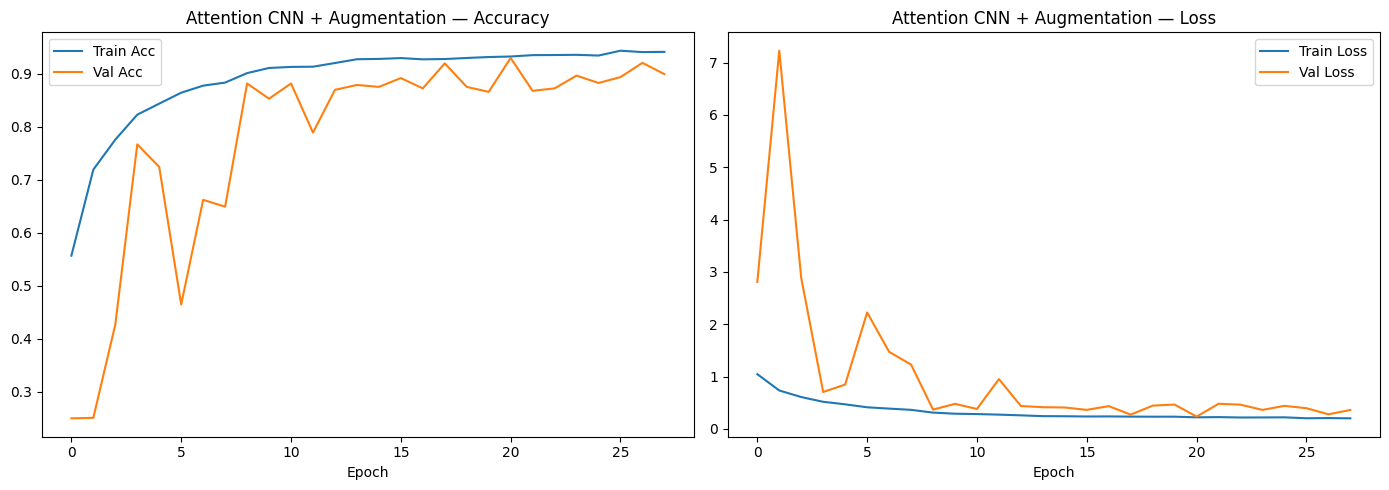


  Attention CNN + Augmentation
  Overall Accuracy : 93.70%
  Macro F1-Score   : 93.66%

              precision    recall  f1-score   support

      glioma       0.96      0.94      0.95       270
  meningioma       0.95      0.84      0.89       270
     notumor       0.97      0.97      0.97       270
   pituitary       0.87      1.00      0.93       270

    accuracy                           0.94      1080
   macro avg       0.94      0.94      0.94      1080
weighted avg       0.94      0.94      0.94      1080



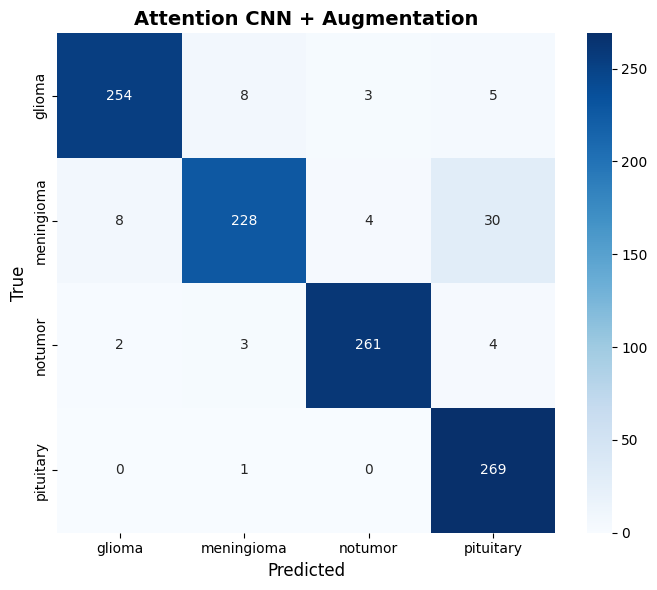

In [12]:
print("\n" + "─"*60)
print("EXPERIMENT 4: With Controlled Data Augmentation")
print("─"*60)
 
train_gen_aug, val_gen_aug, test_gen_aug = make_generators(
    train_data, val_data, test_data, augment=True)
 
attn_aug_model = build_attention_cnn()
attn_aug_model.compile(optimizer=keras.optimizers.Adam(LR),
                        loss="categorical_crossentropy", metrics=["accuracy"])
 
hist_aug = attn_aug_model.fit(
    train_gen_aug, validation_data=val_gen_aug,
    epochs=EPOCHS_BASE + EPOCHS_FINE,
    callbacks=attn_cbs,
    class_weight=class_weight_dict,
    verbose=1)
 
plot_history(hist_aug, "Attention CNN + Augmentation")
y_true_aug, y_pred_aug, acc_aug, p_aug, r_aug, f_aug = evaluate_model(
    attn_aug_model, test_gen_aug, title="Attention CNN + Augmentation")
plot_confusion_matrix(y_true_aug, y_pred_aug, "Attention CNN + Augmentation")
attn_aug_model.save(str(WORKING_DIR / "attn_aug_model.h5"))

# EXPERIMENT 5: GENERATIVE DATA AUGMENTATION — DCGAN (PyTorch)

In [13]:
print("\n" + "─"*60)
print("EXPERIMENT 5: DCGAN for Synthetic MRI Generation")
print("─"*60)
 
GAN_IMG_SIZE   = 64      # keep light for Kaggle T4
GAN_LATENT_DIM = 128
GAN_EPOCHS     = 100
GAN_BATCH      = 64
GAN_TARGET_CLS = "notumor"  # generate synthetic images for minority-like class
N_GAN_IMAGES   = 200        # how many to generate and add


────────────────────────────────────────────────────────────
EXPERIMENT 5: DCGAN for Synthetic MRI Generation
────────────────────────────────────────────────────────────


# PyTorch Dataset

In [14]:
class MRIGANDataset(Dataset):
    def __init__(self, paths, transform=None):
        self.paths     = paths
        self.transform = transform
 
    def __len__(self):
        return len(self.paths)
 
    def __getitem__(self, idx):
        img = load_img(self.paths[idx], target_size=(GAN_IMG_SIZE, GAN_IMG_SIZE))
        img = img_to_array(img) / 255.0
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)  # CHW
        if self.transform:
            img = self.transform(img)
        return img

# Generator

In [15]:
class DCGANGenerator(nn.Module):
    def __init__(self, latent_dim=GAN_LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            # 1×1 → 4×4
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(True),
            # 4×4 → 8×8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            # 8×8 → 16×16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            # 16×16 → 32×32
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),
            # 32×32 → 64×64
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )
 
    def forward(self, z):
        return self.net(z)

# Discriminator

In [16]:
class DCGANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def block(in_c, out_c, bn=True):
            layers_ = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
            if bn:
                layers_.append(nn.BatchNorm2d(out_c))
            layers_.append(nn.LeakyReLU(0.2, inplace=True))
            return layers_
 
        self.net = nn.Sequential(
            *block(3,   64,  bn=False),
            *block(64,  128),
            *block(128, 256),
            *block(256, 512),
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
 
    def forward(self, x):
        return self.net(x).view(-1)
 
 
def train_dcgan(image_paths, epochs=GAN_EPOCHS, latent_dim=GAN_LATENT_DIM):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"  GAN training on: {device}")
 
    transform = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    dataset    = MRIGANDataset(image_paths, transform=transform)
    dataloader = DataLoader(dataset, batch_size=GAN_BATCH, shuffle=True,
                            num_workers=2, drop_last=True)
 
    G = DCGANGenerator(latent_dim).to(device)
    D = DCGANDiscriminator().to(device)
 
    # Weights init
    def weights_init(m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
 
    G.apply(weights_init); D.apply(weights_init)
 
    criterion   = nn.BCELoss()
    opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
 
    g_losses, d_losses = [], []
 
    for epoch in range(1, epochs + 1):
        g_loss_ep, d_loss_ep = 0.0, 0.0
        for real_imgs in dataloader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)
            real_lbl = torch.ones(bs,  device=device) * 0.9   # label smoothing
            fake_lbl = torch.zeros(bs, device=device)
 
            # ── Train D ──
            opt_D.zero_grad()
            out_real = D(real_imgs)
            loss_d_real = criterion(out_real, real_lbl)
 
            z = torch.randn(bs, latent_dim, 1, 1, device=device)
            fake_imgs = G(z).detach()
            out_fake = D(fake_imgs)
            loss_d_fake = criterion(out_fake, fake_lbl)
 
            loss_d = (loss_d_real + loss_d_fake) * 0.5
            loss_d.backward(); opt_D.step()
 
            # ── Train G ──
            opt_G.zero_grad()
            z = torch.randn(bs, latent_dim, 1, 1, device=device)
            fake_imgs = G(z)
            out = D(fake_imgs)
            loss_g = criterion(out, torch.ones(bs, device=device))
            loss_g.backward(); opt_G.step()
 
            g_loss_ep += loss_g.item()
            d_loss_ep += loss_d.item()
 
        g_losses.append(g_loss_ep / len(dataloader))
        d_losses.append(d_loss_ep / len(dataloader))
 
        if epoch % 20 == 0:
            print(f"  [Epoch {epoch:3d}/{epochs}]  G: {g_losses[-1]:.4f}  D: {d_losses[-1]:.4f}")
 
    # Plot GAN losses
    plt.figure(figsize=(8, 4))
    plt.plot(g_losses, label="Generator Loss")
    plt.plot(d_losses, label="Discriminator Loss")
    plt.title("DCGAN Training Loss"); plt.xlabel("Epoch"); plt.legend()
    plt.tight_layout()
    plt.savefig(WORKING_DIR / "gan_loss.png", dpi=150)
    plt.show()
 
    return G, device
 
 
def generate_and_save(G, device, target_class, n_images, latent_dim=GAN_LATENT_DIM):
    """Generate synthetic images and save to disk in augmented dataset folder."""
    save_dir = AUG_DATA_DIR / target_class
    save_dir.mkdir(parents=True, exist_ok=True)
    G.eval()
    generated = 0
    with torch.no_grad():
        while generated < n_images:
            bs = min(64, n_images - generated)
            z  = torch.randn(bs, latent_dim, 1, 1, device=device)
            imgs = G(z)                         # [-1, 1]
            imgs = (imgs + 1) / 2               # [0, 1]
            for i, img in enumerate(imgs):
                # Upsample to model input size for consistency
                img_np = img.permute(1, 2, 0).cpu().numpy()
                img_np = (img_np * 255).clip(0, 255).astype(np.uint8)
                from PIL import Image as PILImage
                pil = PILImage.fromarray(img_np)
                pil = pil.resize((IMG_SIZE, IMG_SIZE), PILImage.BILINEAR)
                pil.save(str(save_dir / f"gan_{generated+i:04d}.jpg"))
            generated += bs
    print(f"  Saved {n_images} synthetic images → {save_dir}")
    return save_dir
 
 
def copy_real_to_aug_dir(real_samples, aug_base):
    """Copy all real images into augmented dataset structure."""
    for path, label in real_samples:
        dst_dir = aug_base / label
        dst_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy(path, dst_dir / Path(path).name)

# Collect paths for target class from training split

  Training GAN on 1260 'notumor' images ...
  GAN training on: cuda
  [Epoch  20/100]  G: 4.1952  D: 0.2055
  [Epoch  40/100]  G: 4.1216  D: 0.2720
  [Epoch  60/100]  G: 4.8256  D: 0.2194
  [Epoch  80/100]  G: 5.9946  D: 0.2852
  [Epoch 100/100]  G: 6.0953  D: 0.2893


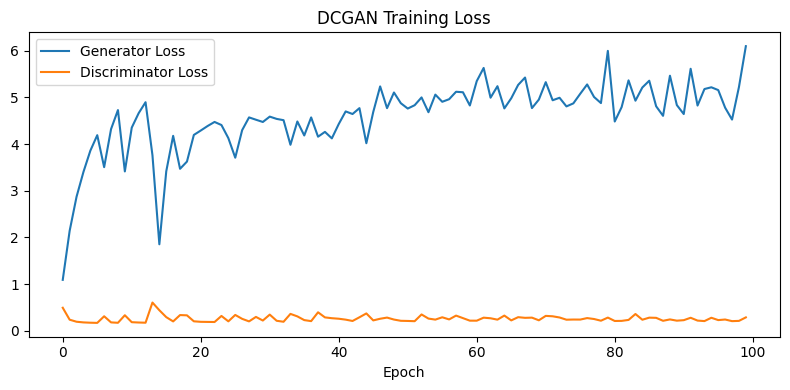

  Saved 200 synthetic images → /kaggle/working/augmented_dataset/notumor


In [17]:
gan_paths = [p for p, l in zip(train_data[0], train_data[1])
             if l == GAN_TARGET_CLS]
print(f"  Training GAN on {len(gan_paths)} '{GAN_TARGET_CLS}' images ...")
 
G_net, gan_device = train_dcgan(gan_paths, epochs=GAN_EPOCHS)
torch.save(G_net.state_dict(), str(WORKING_DIR / "dcgan_generator.pth"))
 
gen_dir = generate_and_save(G_net, gan_device, GAN_TARGET_CLS, N_GAN_IMAGES)

# Visualise a grid of generated images

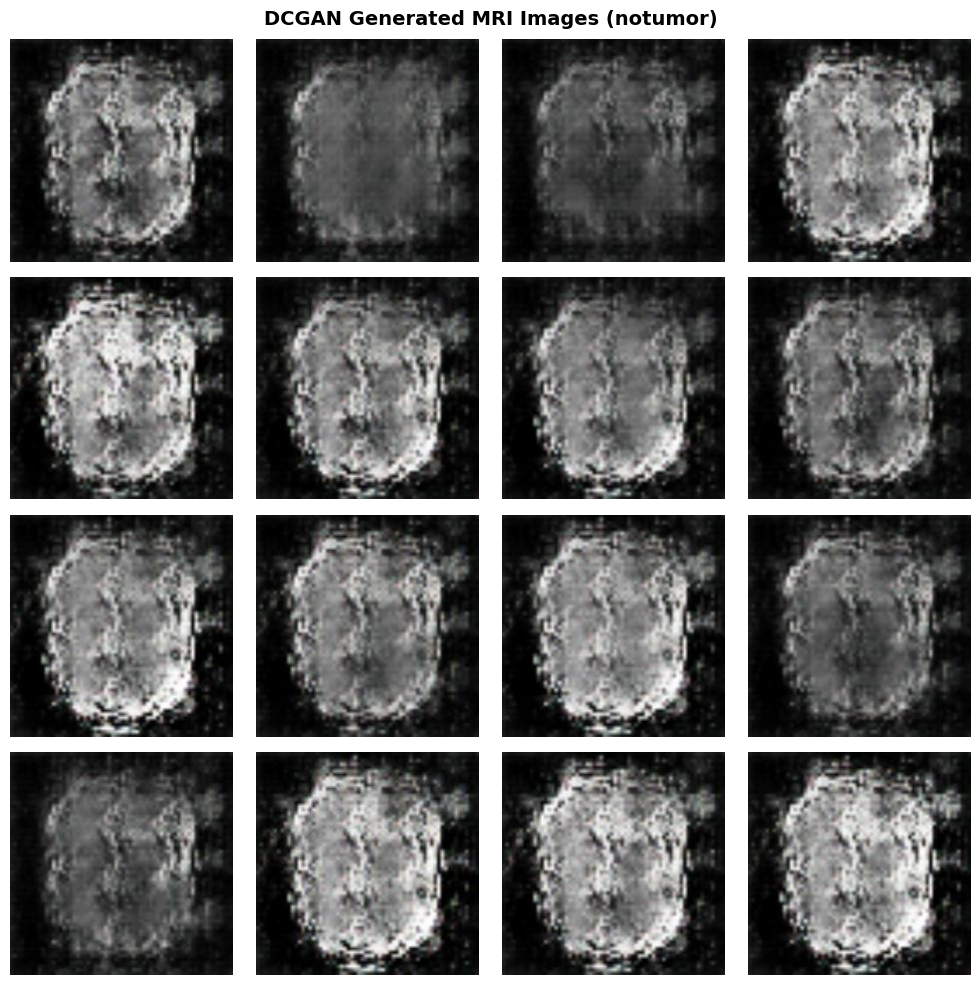

In [18]:
gen_files = sorted(gen_dir.glob("*.jpg"))[:16]
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for ax, fp in zip(axes.flat, gen_files):
    img = load_img(str(fp))
    ax.imshow(img); ax.axis("off")
fig.suptitle("DCGAN Generated MRI Images (notumor)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(WORKING_DIR / "gan_samples.png", dpi=150)
plt.show()

# Build augmented dataset (real + GAN images)

In [19]:
print("  Assembling augmented dataset (real + synthetic) ...")
copy_real_to_aug_dir(list(zip(train_data[0], train_data[1])), AUG_DATA_DIR)
 
# Build augmented train split paths + labels
aug_train_paths, aug_train_labels = [], []
for cls in CLASSES:
    cls_dir = AUG_DATA_DIR / cls
    for f in cls_dir.glob("*.jpg"):
        aug_train_paths.append(str(f))
        aug_train_labels.append(cls)
 
aug_counts = Counter(aug_train_labels)
print("Augmented class distribution:")
for c in CLASSES:
    print(f"  {c:>12}: {aug_counts.get(c, 0)}")
 
aug_train_data = (aug_train_paths, aug_train_labels)
 
# Re-use same val / test splits (no synthetic data in val/test)
train_gen_gan, val_gen_gan, test_gen_gan = make_generators(
    aug_train_data, val_data, test_data, augment=True)

  Assembling augmented dataset (real + synthetic) ...
Augmented class distribution:
        glioma: 1260
    meningioma: 1260
       notumor: 1460
     pituitary: 1260
Found 5240 validated image filenames belonging to 4 classes.
Found 1080 validated image filenames belonging to 4 classes.
Found 1080 validated image filenames belonging to 4 classes.


# Retrain best model (attention CNN) on augmented data

Epoch 1/60
164/164 ━━━━━━━━━━━━━━━━━━━━ 115s 529ms/step - accuracy: 0.4829 - loss: 1.1984 - val_accuracy: 0.2500 - val_loss: 1.7516 - learning_rate: 1.0000e-04
Epoch 2/60
164/164 ━━━━━━━━━━━━━━━━━━━━ 67s 407ms/step - accuracy: 0.7072 - loss: 0.7633 - val_accuracy: 0.3093 - val_loss: 2.4489 - learning_rate: 1.0000e-04
Epoch 3/60
164/164 ━━━━━━━━━━━━━━━━━━━━ 66s 405ms/step - accuracy: 0.7765 - loss: 0.6209 - val_accuracy: 0.2343 - val_loss: 2.6587 - learning_rate: 1.0000e-04
Epoch 4/60
164/164 ━━━━━━━━━━━━━━━━━━━━ 67s 407ms/step - accuracy: 0.8294 - loss: 0.5014 - val_accuracy: 0.7500 - val_loss: 0.7088 - learning_rate: 1.0000e-04
Epoch 5/60
164/164 ━━━━━━━━━━━━━━━━━━━━ 67s 405ms/step - accuracy: 0.8482 - loss: 0.4644 - val_accuracy: 0.7898 - val_loss: 0.5974 - learning_rate: 1.0000e-04
Epoch 6/60
164/164 ━━━━━━━━━━━━━━━━━━━━ 68s 415ms/step - accuracy: 0.8528 - loss: 0.4483 - val_accuracy: 0.7278 - val_loss: 0.8829 - learning_rate: 1.0000e-04
Epoch 7/60
164/164 ━━━━━━━━━━━━━━━━━━━━ 66s 4

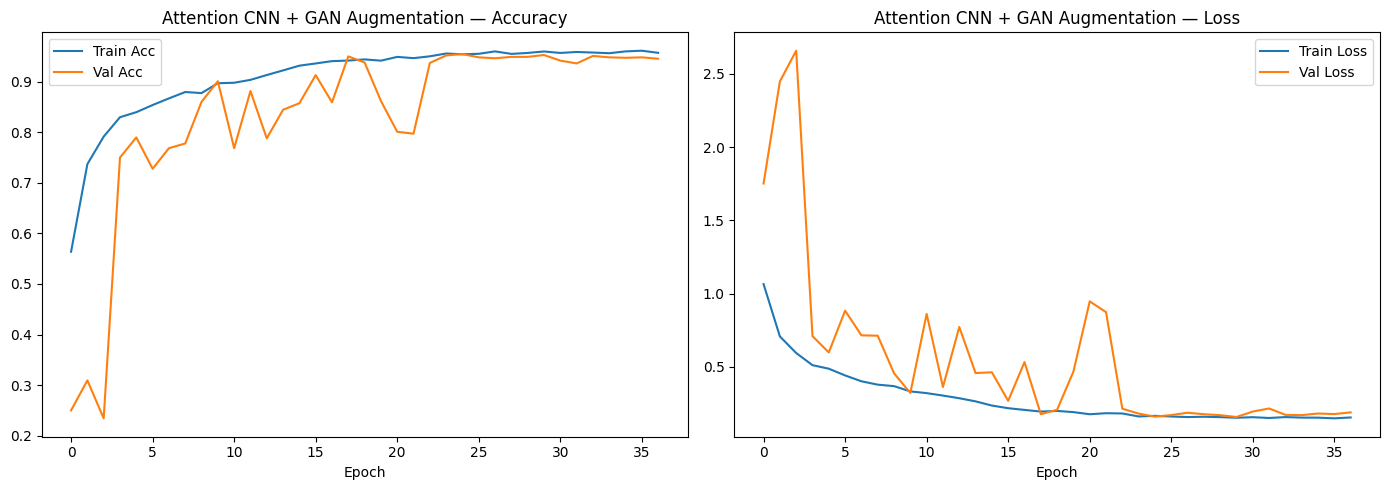


  Attention CNN + GAN Aug
  Overall Accuracy : 95.09%
  Macro F1-Score   : 95.06%

              precision    recall  f1-score   support

      glioma       0.97      0.93      0.95       270
  meningioma       0.96      0.89      0.92       270
     notumor       0.96      0.98      0.97       270
   pituitary       0.92      1.00      0.96       270

    accuracy                           0.95      1080
   macro avg       0.95      0.95      0.95      1080
weighted avg       0.95      0.95      0.95      1080



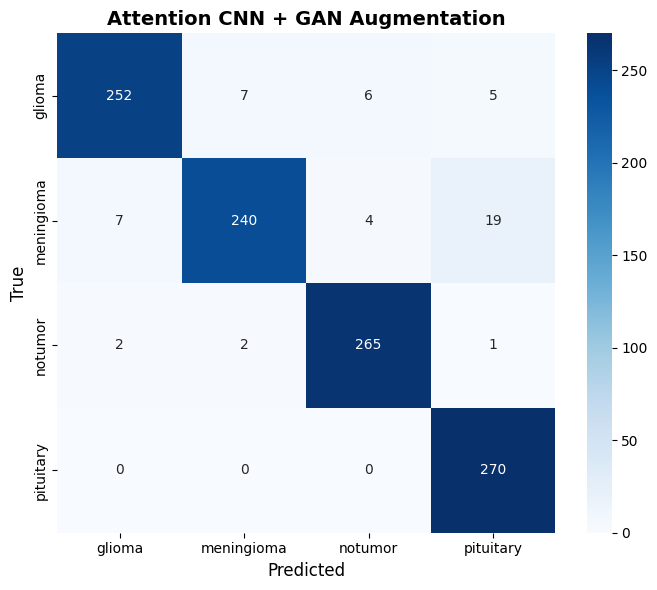

In [20]:
attn_gan_model = build_attention_cnn()
attn_gan_model.compile(optimizer=keras.optimizers.Adam(LR),
                        loss="categorical_crossentropy", metrics=["accuracy"])
 
# Recompute class weights for augmented distribution
y_aug_int = [label2idx[y] for y in aug_train_labels]
cw_aug    = compute_class_weight("balanced",
                                  classes=np.arange(NUM_CLASSES),
                                  y=y_aug_int)
cw_aug_dict = dict(enumerate(cw_aug))
 
hist_gan_model = attn_gan_model.fit(
    train_gen_gan, validation_data=val_gen_gan,
    epochs=EPOCHS_BASE + EPOCHS_FINE,
    callbacks=attn_cbs,
    class_weight=cw_aug_dict,
    verbose=1)
 
plot_history(hist_gan_model, "Attention CNN + GAN Augmentation")
y_true_gan, y_pred_gan, acc_gan, p_gan, r_gan, f_gan = evaluate_model(
    attn_gan_model, test_gen_gan, title="Attention CNN + GAN Aug")
plot_confusion_matrix(y_true_gan, y_pred_gan, "Attention CNN + GAN Augmentation")
attn_gan_model.save(str(WORKING_DIR / "attn_gan_model.h5"))

# SECTION 6: COMPARATIVE VISUALISATIONS


────────────────────────────────────────────────────────────
SECTION 6: Comparative Visualisations
────────────────────────────────────────────────────────────


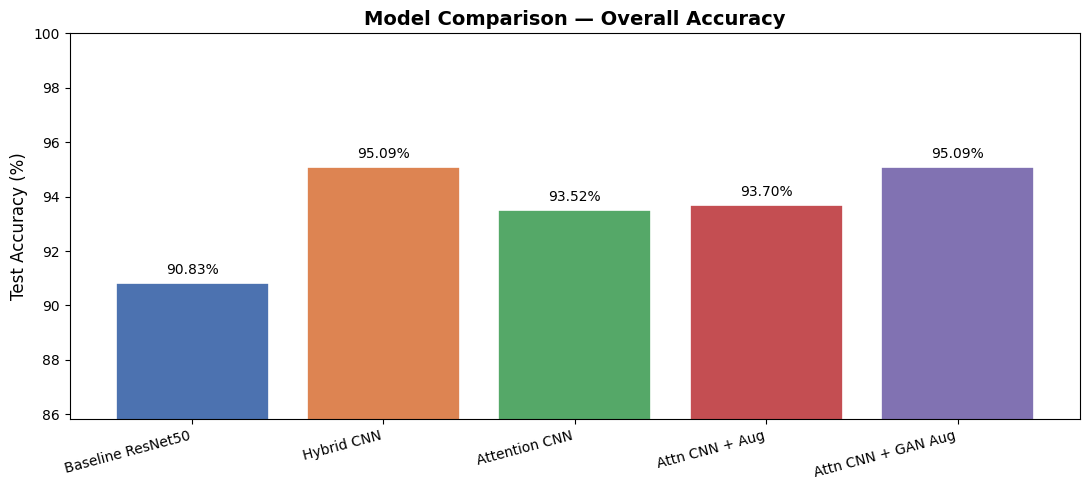

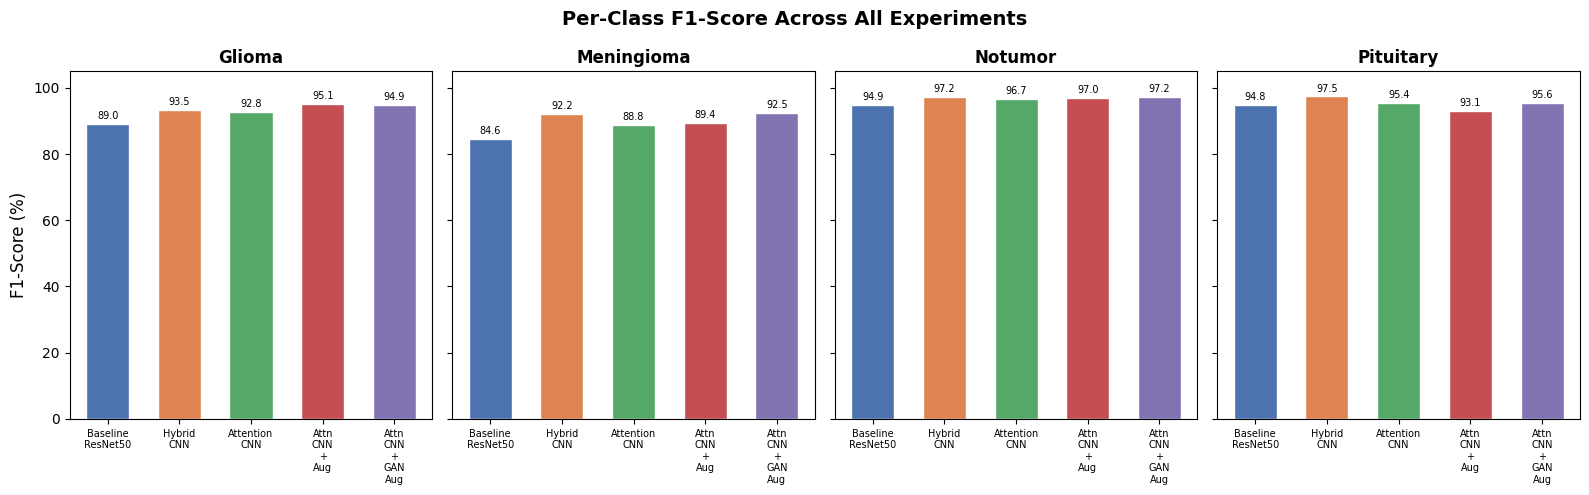

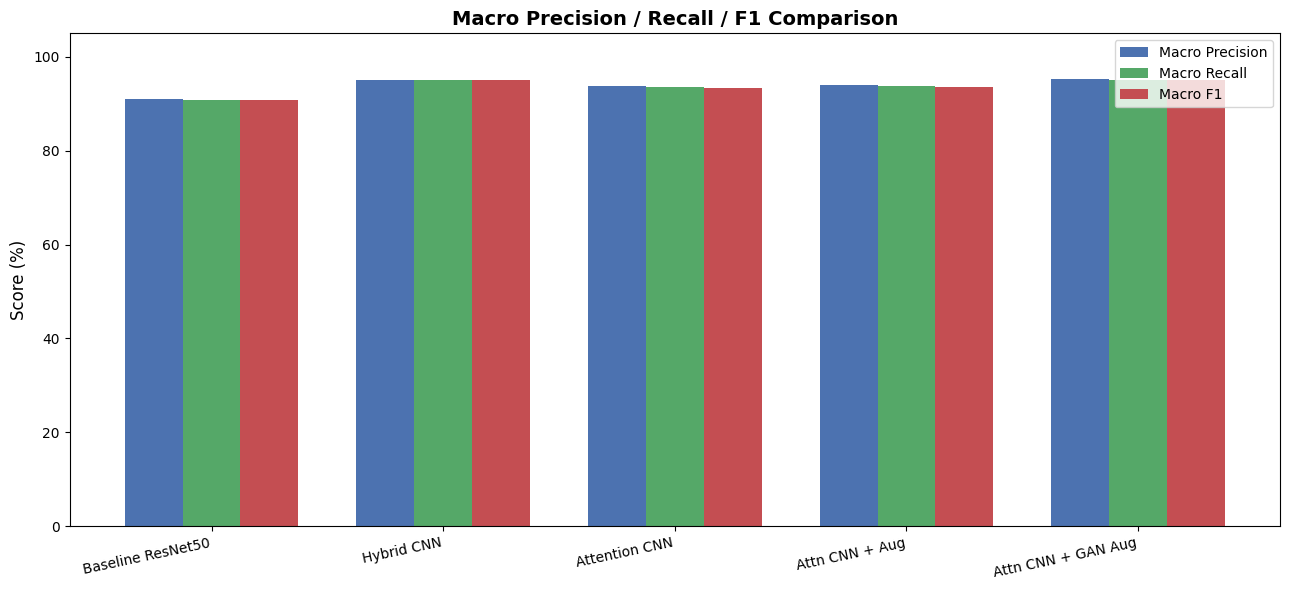


Model                          Accuracy  Precision    Recall        F1
Baseline ResNet50                90.83%     91.00%    90.83%    90.81%
Hybrid CNN                       95.09%     95.08%    95.09%    95.07%
Attention CNN                    93.52%     93.71%    93.52%    93.41%
Attn CNN + Aug                   93.70%     93.98%    93.70%    93.66%
Attn CNN + GAN Aug               95.09%     95.21%    95.09%    95.06%

✅  All experiments complete.
   Output files saved to: /kaggle/working


In [22]:
print("\n" + "─"*60)
print("SECTION 6: Comparative Visualisations")
print("─"*60)
 
experiments = {
    "Baseline ResNet50":        (acc_b,   p_b,   r_b,   f_b),
    "Hybrid CNN":               (acc_h,   p_h,   r_h,   f_h),
    "Attention CNN":            (acc_a,   p_a,   r_a,   f_a),
    "Attn CNN + Aug":           (acc_aug, p_aug, r_aug, f_aug),
    "Attn CNN + GAN Aug":       (acc_gan, p_gan, r_gan, f_gan),
}
 
# ── 6a: Overall accuracy bar chart ───────────────────────────────────────────
names   = list(experiments.keys())
accs    = [v[0] * 100 for v in experiments.values()]
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
 
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(names, accs, color=colors, edgecolor="white", linewidth=1.2)
ax.set_ylim(max(0, min(accs) - 5), 100)
ax.set_ylabel("Test Accuracy (%)", fontsize=12)
ax.set_title("Model Comparison — Overall Accuracy", fontsize=14, fontweight="bold")
ax.bar_label(bars, fmt="%.2f%%", padding=4, fontsize=10)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(WORKING_DIR / "comparison_accuracy.png", dpi=150)
plt.show()
 
# ── 6b: Per-class F1-score comparison ────────────────────────────────────────
fig, axes = plt.subplots(1, len(CLASSES), figsize=(16, 5), sharey=True)
x = np.arange(len(experiments))
w = 0.6
 
for ci, cls in enumerate(CLASSES):
    f1_vals = [experiments[m][3][ci] * 100 for m in names]
    bars = axes[ci].bar(x, f1_vals, width=w, color=colors, edgecolor="white")
    axes[ci].set_title(cls.capitalize(), fontsize=12, fontweight="bold")
    axes[ci].set_xticks(x)
    axes[ci].set_xticklabels([n.replace(" ", "\n") for n in names], fontsize=7)
    axes[ci].set_ylim(0, 105)
    axes[ci].bar_label(bars, fmt="%.1f", padding=2, fontsize=7)
 
axes[0].set_ylabel("F1-Score (%)", fontsize=12)
fig.suptitle("Per-Class F1-Score Across All Experiments", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(WORKING_DIR / "per_class_f1.png", dpi=150)
plt.show()
 
# ── 6c: Precision / Recall / F1 grouped bar chart (macro averages) ───────────
macro_p  = [np.mean(v[1]) * 100 for v in experiments.values()]
macro_r  = [np.mean(v[2]) * 100 for v in experiments.values()]
macro_f1 = [np.mean(v[3]) * 100 for v in experiments.values()]
 
x  = np.arange(len(names))
bw = 0.25
 
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - bw, macro_p,  bw, label="Macro Precision", color="#4C72B0")
ax.bar(x,      macro_r,  bw, label="Macro Recall",    color="#55A868")
ax.bar(x + bw, macro_f1, bw, label="Macro F1",        color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=12, ha="right")
ax.set_ylim(0, 105)
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_title("Macro Precision / Recall / F1 Comparison", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(WORKING_DIR / "macro_prf1.png", dpi=150)
plt.show()
 
# ── 6d: Summary table ─────────────────────────────────────────────────────────
print("\n" + "="*75)
print(f"{'Model':<28} {'Accuracy':>10} {'Precision':>10} {'Recall':>9} {'F1':>9}")
print("="*75)
for name, (acc, p, r, f) in experiments.items():
    print(f"{name:<28} {acc*100:>9.2f}% {np.mean(p)*100:>9.2f}% "
          f"{np.mean(r)*100:>8.2f}% {np.mean(f)*100:>8.2f}%")
print("="*75)
 
print("\n✅  All experiments complete.")
print(f"   Output files saved to: {WORKING_DIR}")